In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


Loading dataset... (mungkin agak lama)
Total data asli   : 88800 baris
Jumlah kelas      : 26


C:\Users\User\AppData\Local\Temp\ipykernel_11792\1628545166.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=SAMPLES_PER_CLASS, random_state=42))



Total sampel      : 2600 (26 kelas × 100 sampel)
Kelas unik        : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]
Shape pixel       : (2600, 784)


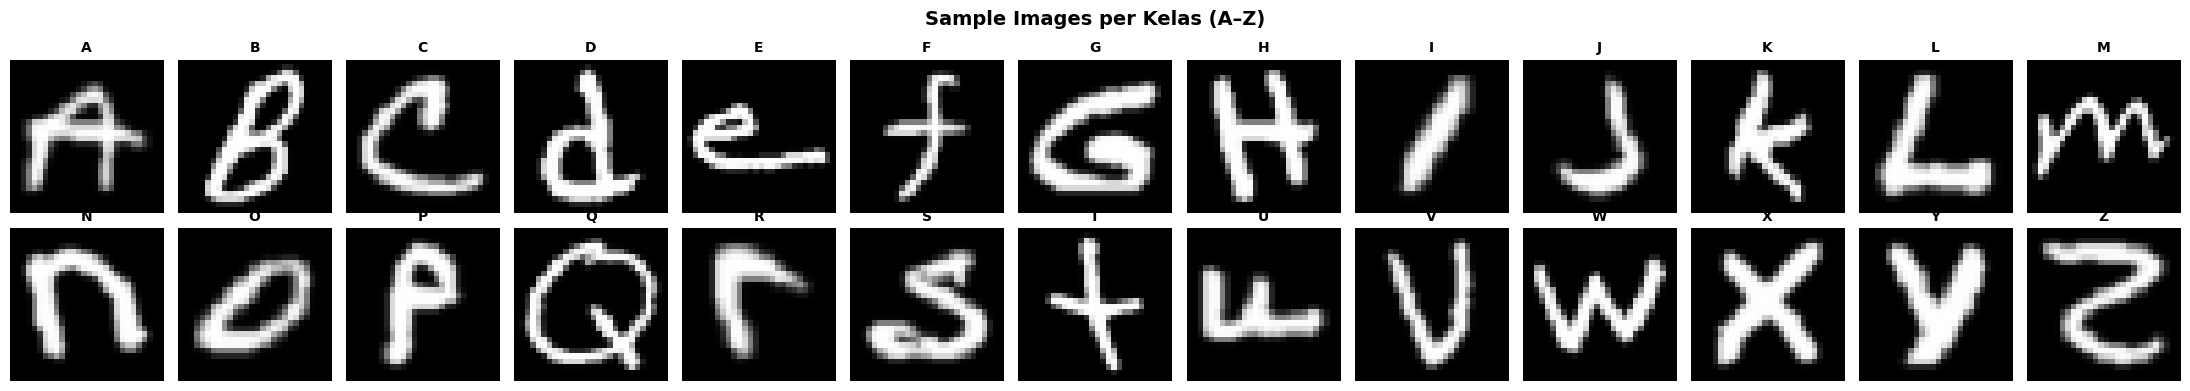

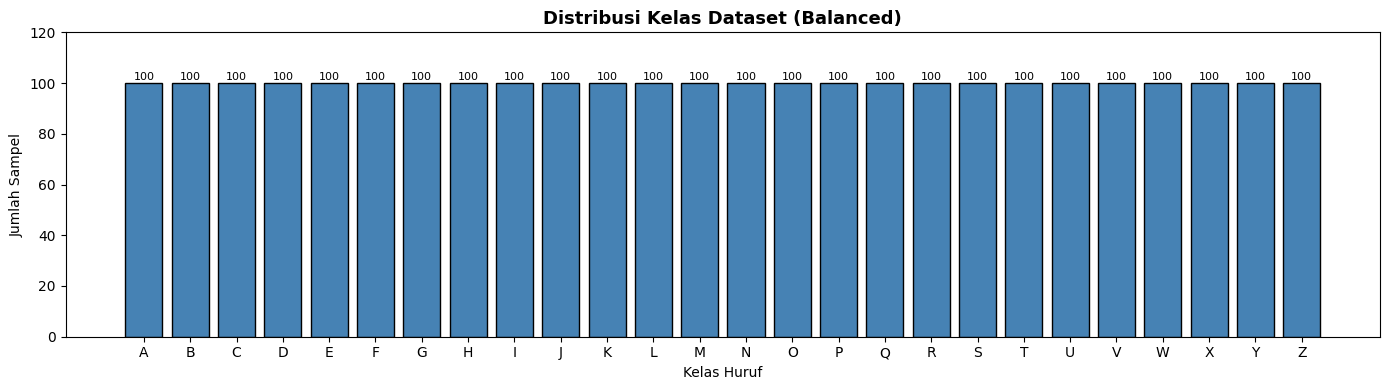

✅ Visualisasi dataset selesai!


In [ ]:
SAMPLES_PER_CLASS = 100
N_CLASSES         = 26
TOTAL_SAMPLES     = SAMPLES_PER_CLASS * N_CLASSES

print("Loading dataset... (mungkin agak lama)")
df = pd.read_csv('data/emnist-letters-train.csv', header=None)
print(f"Total data asli   : {len(df)} baris")
print(f"Jumlah kelas      : {df[0].nunique()}")

df_balanced = (df.groupby(0)
                 .apply(lambda x: x.sample(n=SAMPLES_PER_CLASS, random_state=42))
                 .reset_index(drop=True))

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

labels = df_balanced.iloc[:, 0].values
pixels = df_balanced.iloc[:, 1:].values

print(f"\nTotal sampel      : {TOTAL_SAMPLES} ({N_CLASSES} kelas × {SAMPLES_PER_CLASS} sampel)")
print(f"Kelas unik        : {np.unique(labels)}")
print(f"Shape pixel       : {pixels.shape}")

_, unique_idx = np.unique(labels, return_index=True)
fig, axes = plt.subplots(2, 13, figsize=(22, 4))
axes = axes.flat
for i, idx in enumerate(unique_idx):
    img = pixels[idx].reshape(28, 28).T
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{chr(64+labels[idx])}", fontsize=10, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Sample Images per Kelas (A–Z)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

unique, counts = np.unique(labels, return_counts=True)
letter_labels  = [chr(64+u) for u in unique]

plt.figure(figsize=(14, 4))
bars = plt.bar(letter_labels, counts, color='steelblue', edgecolor='black')
for bar, c in zip(bars, counts):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(c),
             ha='center', va='bottom', fontsize=8)
plt.title('Distribusi Kelas Dataset (Balanced)', fontsize=13, fontweight='bold')
plt.xlabel('Kelas Huruf')
plt.ylabel('Jumlah Sampel')
plt.ylim(0, 120)
plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Visualisasi dataset selesai!")

Mengekstrak fitur HOG...
Shape fitur HOG     : (2600, 1296)
Jumlah fitur/gambar : 1296


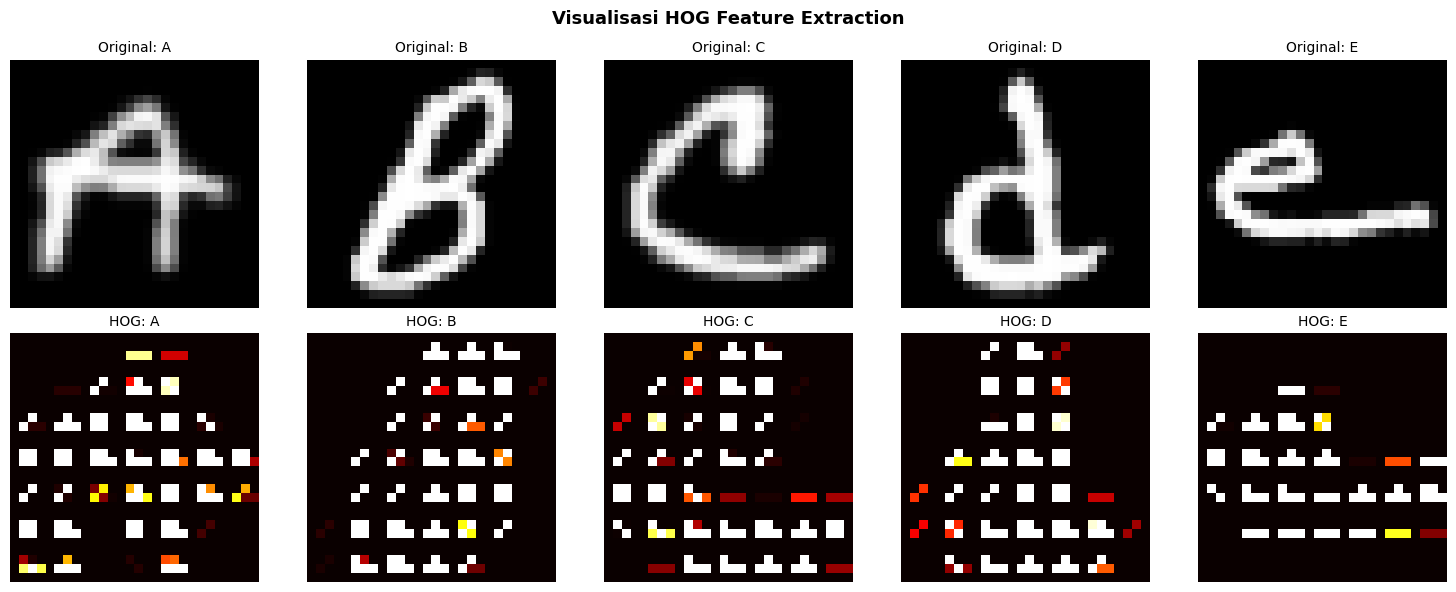

✅ HOG extraction selesai!


In [ ]:
HOG_PARAMS = dict(
    orientations    = 9,
    pixels_per_cell = (4, 4),
    cells_per_block = (2, 2),
    block_norm      = 'L2-Hys',
    visualize       = False,
    feature_vector  = True
)

def extract_hog_features(images):
    features = []
    for img in images:
        img_2d = img.reshape(28, 28).T
        feat   = hog(img_2d, **HOG_PARAMS)
        features.append(feat)
    return np.array(features)

print("Mengekstrak fitur HOG...")
X = extract_hog_features(pixels)
y = labels
print(f"Shape fitur HOG     : {X.shape}")
print(f"Jumlah fitur/gambar : {X.shape[1]}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_indices = [np.where(labels == c)[0][0] for c in range(1, 6)]

for col, idx in enumerate(sample_indices):
    img_2d = pixels[idx].reshape(28, 28).T
    hog_feat, hog_img = hog(img_2d,
                             orientations=9,
                             pixels_per_cell=(4, 4),
                             cells_per_block=(2, 2),
                             block_norm='L2-Hys',
                             visualize=True,
                             feature_vector=True)
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[0, col].imshow(img_2d, cmap='gray')
    axes[0, col].set_title(f"Original: {chr(64+labels[idx])}", fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(hog_img_rescaled, cmap='hot')
    axes[1, col].set_title(f"HOG: {chr(64+labels[idx])}", fontsize=10)
    axes[1, col].axis('off')

plt.suptitle('Visualisasi HOG Feature Extraction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_hog_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ HOG extraction selesai!")

Data Training : 2080 sampel (80%)
Data Testing  : 520 sampel (20%)

Menjalankan Grid Search... (tunggu beberapa menit)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Parameter SVM terbaik : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Akurasi CV terbaik    : 84.57%


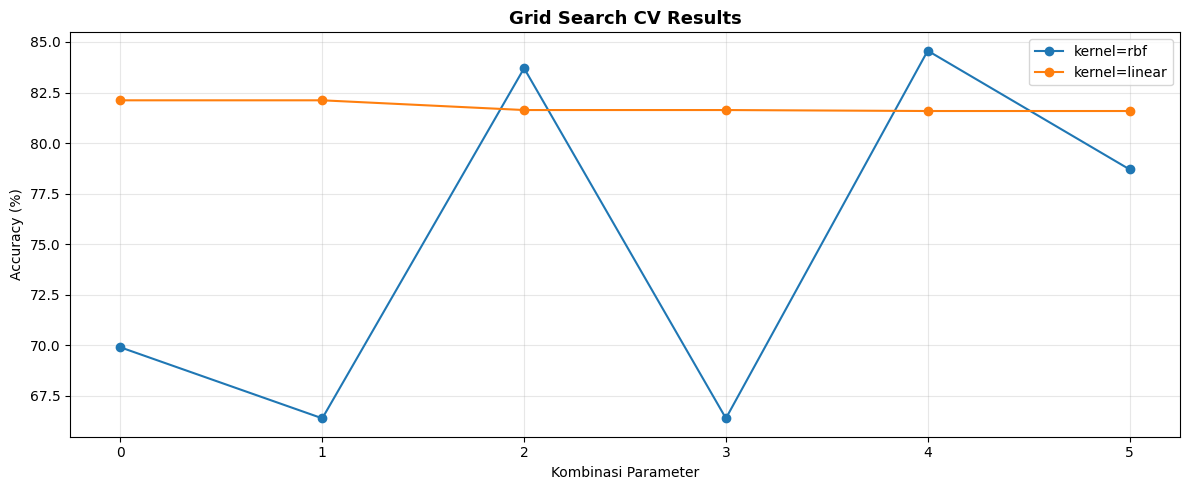

✅ Grid Search selesai!


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data Training : {X_train.shape[0]} sampel (80%)")
print(f"Data Testing  : {X_test.shape[0]} sampel (20%)\n")

param_grid = {
    'C'      : [0.1, 1, 10],
    'kernel' : ['rbf', 'linear'],
    'gamma'  : ['scale', 'auto']
}

print("Menjalankan Grid Search... (tunggu beberapa menit)")
grid_search = GridSearchCV(SVC(random_state=42), param_grid,
                           cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\n✅ Parameter SVM terbaik : {grid_search.best_params_}")
print(f"✅ Akurasi CV terbaik    : {grid_search.best_score_*100:.2f}%")

results  = pd.DataFrame(grid_search.cv_results_)
fig, ax  = plt.subplots(figsize=(12, 5))
for kernel in ['rbf', 'linear']:
    subset = results[results['param_kernel'] == kernel]
    ax.plot(range(len(subset)), subset['mean_test_score']*100,
            marker='o', label=f'kernel={kernel}')
ax.set_title('Grid Search CV Results', fontsize=13, fontweight='bold')
ax.set_xlabel('Kombinasi Parameter')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_grid_search_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Grid Search selesai!")

In [12]:
print("Menjalankan LOOCV (StratifiedKFold 5-Fold)...")
best_model = grid_search.best_estimator_
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc  = cross_val_score(best_model, X, y, cv=skf, scoring='accuracy')
cv_prec = cross_val_score(best_model, X, y, cv=skf, scoring='precision_macro')
cv_rec  = cross_val_score(best_model, X, y, cv=skf, scoring='recall_macro')
cv_f1   = cross_val_score(best_model, X, y, cv=skf, scoring='f1_macro')

print("\n" + "="*55)
print(f"{'HASIL LOOCV (5-Fold Cross Validation)':^55}")
print("="*55)
print(f"{'Metrik':<15} {'Mean':>10} {'Std Dev':>12}")
print("-"*55)
print(f"{'Accuracy':<15} {cv_acc.mean():>10.4f} {cv_acc.std():>12.4f}")
print(f"{'Precision':<15} {cv_prec.mean():>10.4f} {cv_prec.std():>12.4f}")
print(f"{'Recall':<15} {cv_rec.mean():>10.4f} {cv_rec.std():>12.4f}")
print(f"{'F1-Score':<15} {cv_f1.mean():>10.4f} {cv_f1.std():>12.4f}")
print("="*55)
print("\nPer-fold Accuracy:")
for i, acc in enumerate(cv_acc):
    print(f"  Fold {i+1}: {acc*100:.2f}%")
print("✅ LOOCV selesai!")

Menjalankan LOOCV (StratifiedKFold 5-Fold)...

         HASIL LOOCV (5-Fold Cross Validation)         
Metrik                Mean      Std Dev
-------------------------------------------------------
Accuracy            0.8438       0.0120
Precision           0.8504       0.0082
Recall              0.8438       0.0120
F1-Score            0.8440       0.0107

Per-fold Accuracy:
  Fold 1: 84.62%
  Fold 2: 83.27%
  Fold 3: 83.27%
  Fold 4: 86.54%
  Fold 5: 84.23%
✅ LOOCV selesai!


Metric                 Training         Testing
Accuracy                 1.0000          0.8115
Precision                1.0000          0.8159
Recall                   1.0000          0.8115
F1                       1.0000          0.8116


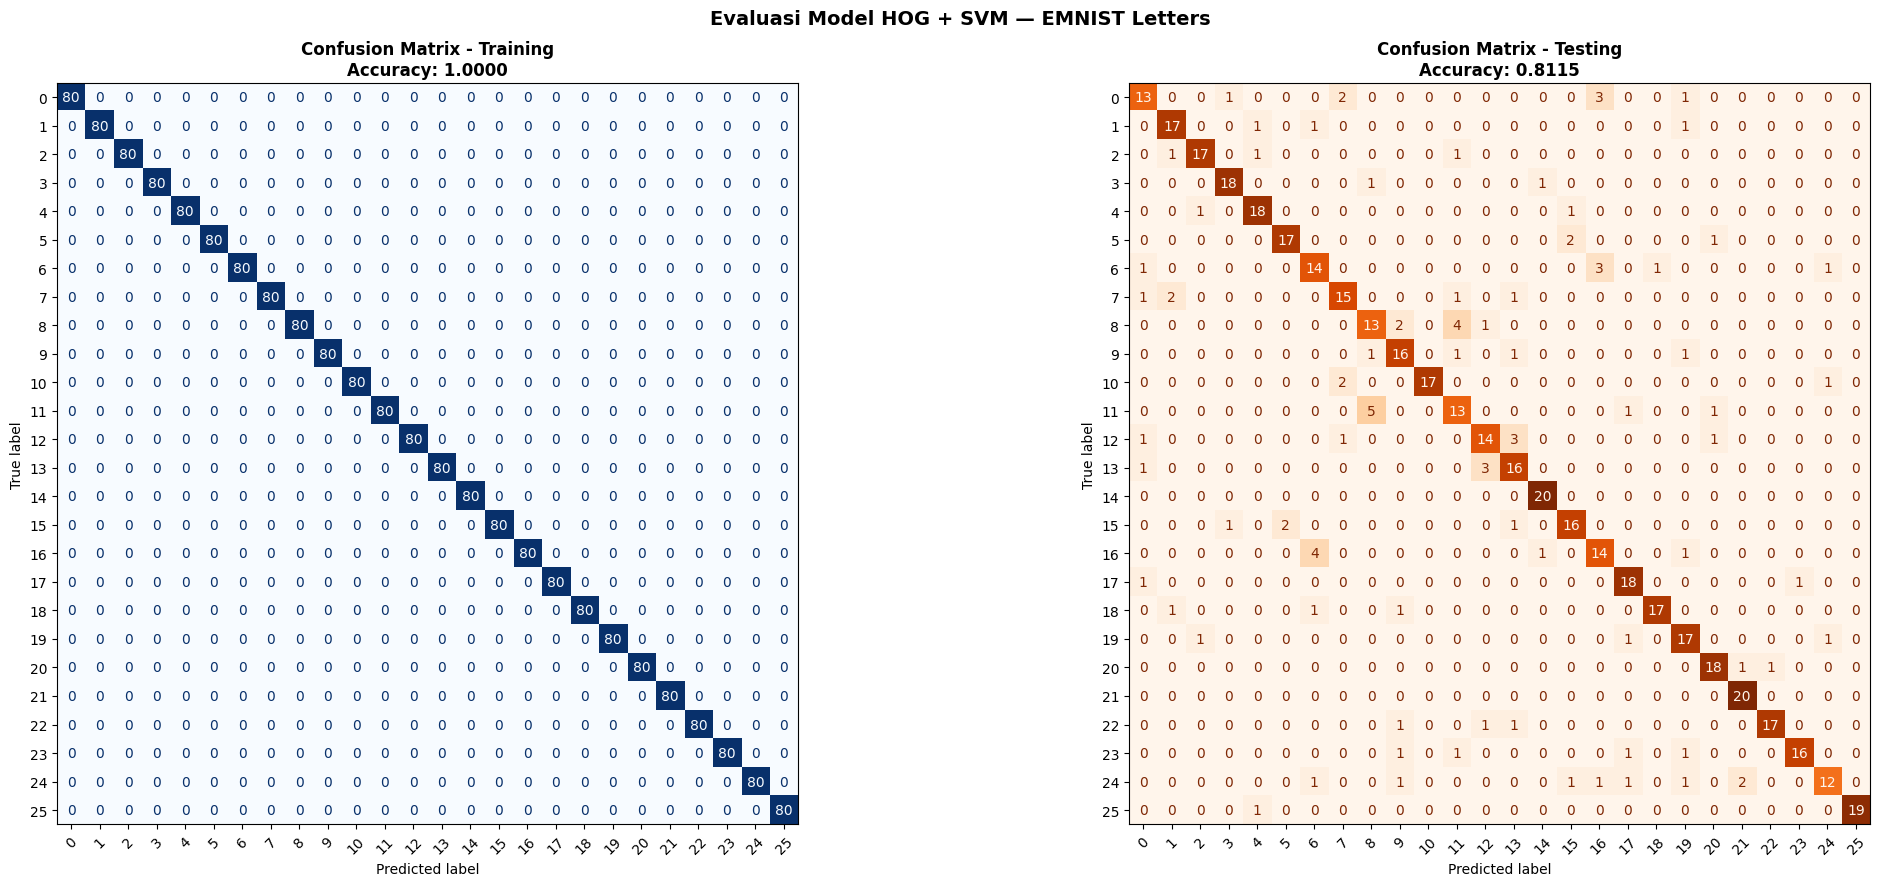

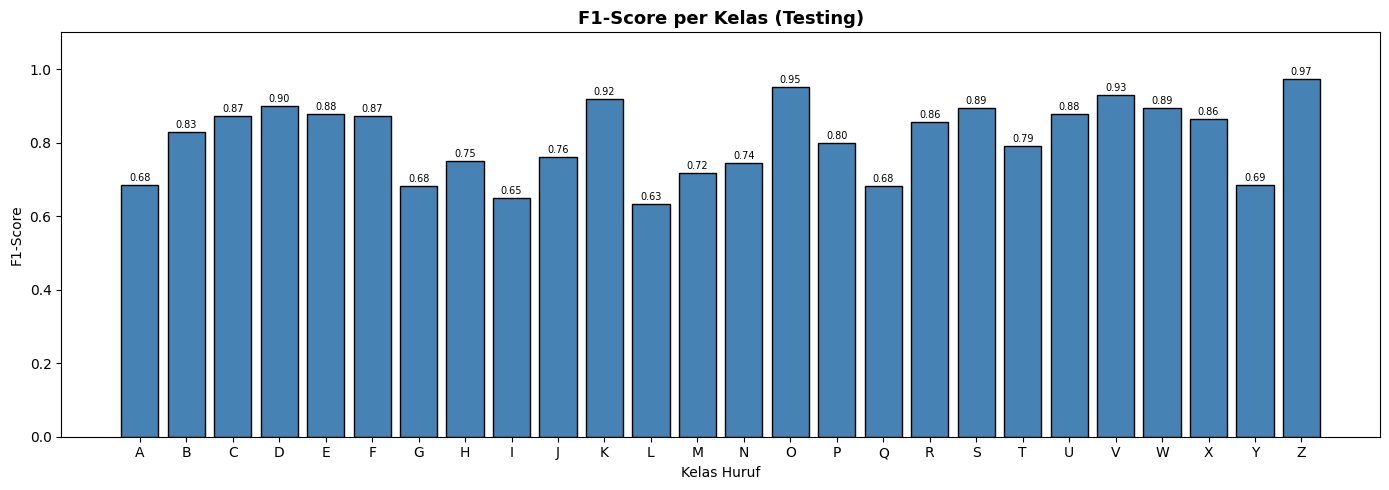

✅ Evaluasi selesai!


In [ ]:
best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

train_metrics = {
    'accuracy' : accuracy_score(y_train, y_pred_train),
    'precision': precision_score(y_train, y_pred_train, average='macro', zero_division=0),
    'recall'   : recall_score(y_train, y_pred_train, average='macro', zero_division=0),
    'f1'       : f1_score(y_train, y_pred_train, average='macro', zero_division=0),
}
test_metrics = {
    'accuracy' : accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test, average='macro', zero_division=0),
    'recall'   : recall_score(y_test, y_pred_test, average='macro', zero_division=0),
    'f1'       : f1_score(y_test, y_pred_test, average='macro', zero_division=0),
}

print("="*55)
print(f"{'Metric':<15} {'Training':>15} {'Testing':>15}")
print("="*55)
for m in ['accuracy','precision','recall','f1']:
    print(f"{m.capitalize():<15} {train_metrics[m]:>15.4f} {test_metrics[m]:>15.4f}")
print("="*55)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train)).plot(
    ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title(f"Confusion Matrix - Training\nAccuracy: {train_metrics['accuracy']:.4f}",
                  fontsize=12, fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test)).plot(
    ax=axes[1], cmap='Oranges', colorbar=False, xticks_rotation=45)
axes[1].set_title(f"Confusion Matrix - Testing\nAccuracy: {test_metrics['accuracy']:.4f}",
                  fontsize=12, fontweight='bold')

plt.suptitle('Evaluasi Model HOG + SVM — EMNIST Letters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

f1_per_class = f1_score(y_test, y_pred_test, average=None, zero_division=0)
letter_labels = [chr(64+i) for i in range(1, 27)]
plt.figure(figsize=(14, 5))
bars = plt.bar(letter_labels, f1_per_class, color='steelblue', edgecolor='black')
for bar, val in zip(bars, f1_per_class):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.2f}', ha='center', va='bottom', fontsize=7)
plt.title('F1-Score per Kelas (Testing)', fontsize=13, fontweight='bold')
plt.xlabel('Kelas Huruf')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('06_f1_per_class.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Evaluasi selesai!")

In [14]:
print("=" * 60)
print(f"{'RINGKASAN HASIL MIDTERM PROJECT':^60}")
print("=" * 60)
print(f"  Dataset         : EMNIST Letters")
print(f"  Total sampel    : {TOTAL_SAMPLES} ({N_CLASSES} kelas × {SAMPLES_PER_CLASS} sampel)")
print(f"  Training        : {X_train.shape[0]} sampel (80%)")
print(f"  Testing         : {X_test.shape[0]} sampel (20%)")
print(f"\n  HOG Parameters :")
print(f"    orientations    = 9")
print(f"    pixels_per_cell = (4, 4)")
print(f"    cells_per_block = (2, 2)")
print(f"    block_norm      = L2-Hys")
print(f"    Dimensi fitur   = {X_train.shape[1]}")
print(f"\n  SVM Parameters (Best) :")
for k, v in grid_search.best_params_.items():
    print(f"    {k:<10} = {v}")
print(f"\n  Performance Metrics:")
print(f"  {'Metric':<12} {'Training':>12} {'Testing':>12}")
print(f"  {'-'*36}")
for m in ['accuracy','precision','recall','f1']:
    print(f"  {m.capitalize():<12} {train_metrics[m]:>12.4f} {test_metrics[m]:>12.4f}")
print("=" * 60)

              RINGKASAN HASIL MIDTERM PROJECT               
  Dataset         : EMNIST Letters
  Total sampel    : 2600 (26 kelas × 100 sampel)
  Training        : 2080 sampel (80%)
  Testing         : 520 sampel (20%)

  HOG Parameters :
    orientations    = 9
    pixels_per_cell = (4, 4)
    cells_per_block = (2, 2)
    block_norm      = L2-Hys
    Dimensi fitur   = 1296

  SVM Parameters (Best) :
    C          = 10
    gamma      = scale
    kernel     = rbf

  Performance Metrics:
  Metric           Training      Testing
  ------------------------------------
  Accuracy           1.0000       0.8115
  Precision          1.0000       0.8159
  Recall             1.0000       0.8115
  F1                 1.0000       0.8116
